<a href="https://colab.research.google.com/github/Rei5ende/pytorch-bc-study/blob/main/02_neural_network/mnist_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#mnist

###데이터불러오기

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms

# -----------------------------------------------
# 1. 데이터 전처리 설정
# -----------------------------------------------

# MNIST 이미지는 기본적으로 PIL 형식 (0~255 픽셀값)
# 아래 두 가지 변환을 순서대로 적용

transform = transforms.Compose([
    # PIL 이미지 → PyTorch 텐서로 변환
    # 픽셀값 0~255 → 0.0~1.0 범위로 자동 변환됨
    transforms.ToTensor(),

    # 정규화: 평균 0.5, 표준편차 0.5 기준으로 값을 조정
    # 결과적으로 픽셀값이 -1.0~1.0 범위가 됨
    # → 학습이 더 안정적으로 진행됨
    transforms.Normalize((0.5,), (0.5,))
])

# -----------------------------------------------
# 2. 데이터 다운로드
# -----------------------------------------------

# train=True  → 학습용 데이터 60,000개
# train=False → 테스트용 데이터 10,000개
# download=True → 없으면 자동으로 인터넷에서 받아옴
train_data = datasets.MNIST(root='./data', train=True,
                             download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False,
                             download=True, transform=transform)

# -----------------------------------------------
# 3. DataLoader 설정
# -----------------------------------------------

# DataLoader = 데이터를 배치(batch) 단위로 잘라서 모델에 공급하는 역할
# batch_size=64 → 한 번에 64개 이미지씩 학습
# shuffle=True  → 매 epoch마다 데이터 순서를 섞음 (학습 데이터만)
# shuffle=False → 테스트는 순서 유지 (결과 재현성을 위해)
train_loader = torch.utils.data.DataLoader(train_data,
                                            batch_size=64,
                                            shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_data,
                                            batch_size=64,
                                            shuffle=False)

print(f"학습 데이터: {len(train_data)}개")
print(f"테스트 데이터: {len(test_data)}개")

# -----------------------------------------------
# 4. 데이터 shape 확인
# -----------------------------------------------

# next(iter(...)) → DataLoader에서 첫 번째 배치 하나만 꺼내옴
images, labels = next(iter(train_loader))

# images.shape → (배치크기, 채널수, 높이, 너비)
# MNIST는 흑백이라 채널 1개 → (64, 1, 28, 28)
print(f"배치 이미지 shape: {images.shape}")

# labels.shape → (배치크기,) → 각 이미지의 정답 숫자
# 예: tensor([3, 7, 1, 0, ...])
print(f"배치 레이블 shape: {labels.shape}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.09MB/s]


학습 데이터: 60000개
테스트 데이터: 10000개
배치 이미지 shape: torch.Size([64, 1, 28, 28])
배치 레이블 shape: torch.Size([64])


###이미지 시각화

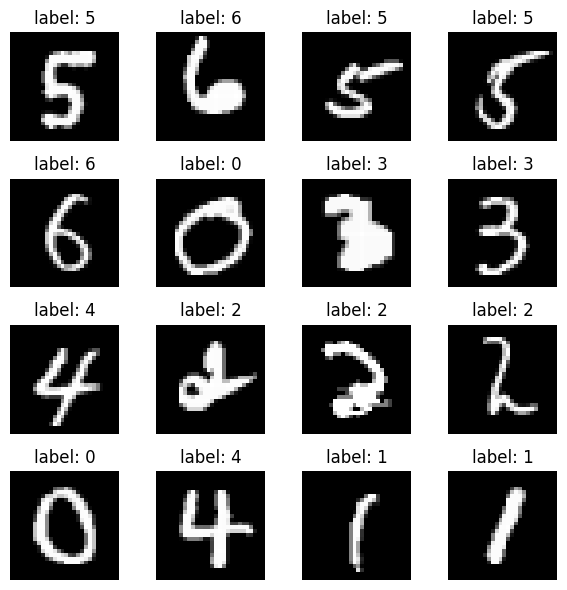

In [ ]:
import matplotlib.pyplot as plt

# 첫 번째 배치에서 이미지 16개 시각화
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    # 이미지 shape: (1, 28, 28) → (28, 28)로 squeeze
    # 정규화된 값(-1~1)을 시각화하기 위해 cmap='gray' 사용
    ax.imshow(images[i].squeeze(), cmap='gray')

    # 정답 레이블 표시
    ax.set_title(f"label: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()

###모델정의

In [3]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # 28×28 이미지를 1차원으로 펼침 → 784개 값
            nn.Flatten(),

            # 첫 번째 레이어: 784 → 128
            nn.Linear(784, 128),
            nn.ReLU(),  # 음수는 0으로, 양수는 그대로 (비선형성 추가)

            # 두 번째 레이어: 128 → 64
            nn.Linear(128, 64),
            nn.ReLU(),

            # 출력 레이어: 64 → 10 (숫자 0~9, 10개 클래스)
            nn.Linear(64, 10)
            # CrossEntropyLoss가 내부적으로 Softmax를 포함하므로
            # 여기서는 Softmax를 따로 붙이지 않음
        )

    def forward(self, x):
        return self.model(x)

# 모델 생성
model = MNISTClassifier()

# 모델 구조 확인
print(model)

# 전체 파라미터 수 확인
total = sum(p.numel() for p in model.parameters())
print(f"\n전체 파라미터 수: {total:,}개")

MNISTClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

전체 파라미터 수: 109,386개


파라미터는 weight와 bias 두 가지로 구성. `nn.Linear(입력, 출력)`에서 weight는 입력×출력, bias는 출력 개수만큼 생김.

레이어별로 보면:

*   첫 번째 Linear(784→128):
    ```
    weight 784 × 128 = 100,352개
    bias 128개
    총 100,352 + 128 = 100,480개
    ```

*   두 번째 Linear(128→64):
    ```
    weight 128 × 64 = 8,192개
    bias 64개
    총 8,192 + 64 = 8,256개
    ```

*   세 번째 Linear(64→10):
    ```
    weight 64 × 10 = 640개
    bias 10개
    총 640 + 10 = 650개
    ```

전부 더하면:
```
100,480 + 8,256 + 650 = **109,386개**
```


첫 번째 레이어에서 대부분의 파라미터가 나오는 이유는 입력이 784(28×28)로 크기 때문.

###학습루프

In [4]:
# 손실함수와 옵티마이저 설정
criterion = nn.CrossEntropyLoss()  # 분류 문제 → CrossEntropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -----------------------------------------------
# 학습 루프
# -----------------------------------------------

epochs = 5  # 전체 데이터를 5번 반복 학습

for epoch in range(epochs):
    model.train()  # 학습 모드 설정
    running_loss = 0.0

    for images, labels in train_loader:
        # 1. 예측 (forward)
        outputs = model(images)

        # 2. Loss 계산
        # outputs: (64, 10) → 각 이미지가 0~9일 확률
        # labels:  (64,)   → 정답 숫자
        loss = criterion(outputs, labels)

        # 3. 기울기 초기화 (이전 배치 기울기가 누적되지 않도록)
        optimizer.zero_grad()

        # 4. 역전파 (각 weight의 기울기 계산)
        loss.backward()

        # 5. 가중치 업데이트
        optimizer.step()

        running_loss += loss.item()

    # epoch당 평균 Loss 출력
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

print("\n학습 완료!")

Epoch 1/5, Loss: 0.3866
Epoch 2/5, Loss: 0.1818
Epoch 3/5, Loss: 0.1318
Epoch 4/5, Loss: 0.1068
Epoch 5/5, Loss: 0.0892

학습 완료!


###정확도 평가

In [5]:
model.eval()  # 평가 모드 (dropout 등 비활성화)

correct = 0  # 맞힌 개수
total = 0    # 전체 개수

# 평가할 때는 기울기 계산이 필요 없으므로 no_grad()로 메모리 절약
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)  # 예측

        # 10개 클래스 중 가장 높은 값의 인덱스 = 예측 숫자
        _, predicted = torch.max(outputs, dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total * 100
print(f"테스트 정확도: {accuracy:.2f}%")
print(f"맞힌 개수: {correct} / {total}")

테스트 정확도: 95.82%
맞힌 개수: 9582 / 10000


###틀린이미지 확인

/tmp/ipykernel_28174/1266855416.py:25: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28174/1266855416.py:25: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28174/1266855416.py:25: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28174/1266855416.py:25: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


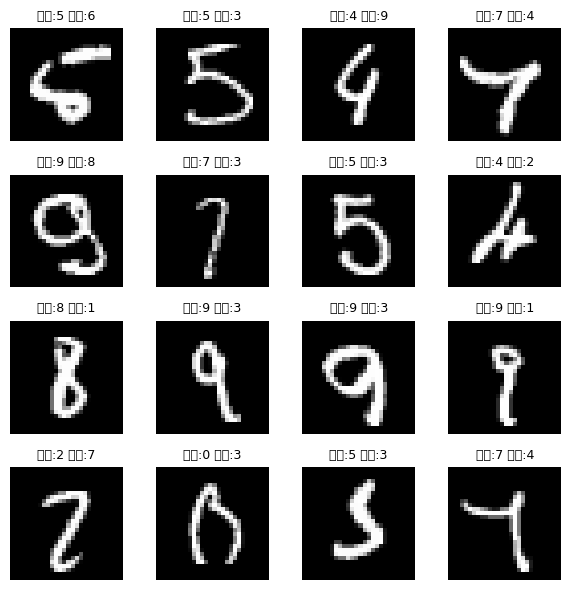

In [12]:
wrong_images = []
wrong_labels = []
wrong_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)

        # 틀린 것만 모으기
        mask = predicted != labels
        wrong_images.extend(images[mask])
        wrong_labels.extend(labels[mask])
        wrong_preds.extend(predicted[mask])

# 틀린 이미지 16개 시각화
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f"정답:{wrong_labels[i].item()} 예측:{wrong_preds[i].item()}",
                 fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# -----------------------------------------------
# 최종 정리 — 전체 파이프라인 한눈에 보기
# -----------------------------------------------

print("=== MNIST 분류기 결과 요약 ===")
print(f"모델 구조: 784 → 128 → 64 → 10")
print(f"파라미터 수: 109,386개")
print(f"학습 데이터: 60,000개")
print(f"테스트 데이터: 10,000개")
print(f"epochs: 5")
print(f"손실함수: CrossEntropyLoss")
print(f"옵티마이저: Adam (lr=0.001)")
print(f"최종 Loss: 0.0892")
print(f"테스트 정확도: 95.82%")

=== MNIST 분류기 결과 요약 ===
모델 구조: 784 → 128 → 64 → 10
파라미터 수: 109,386개
학습 데이터: 60,000개
테스트 데이터: 10,000개
epochs: 5
손실함수: CrossEntropyLoss
옵티마이저: Adam (lr=0.001)
최종 Loss: 0.0892
테스트 정확도: 95.82%
